# Bike-share staffing

## 1. Start Spark

`SparkSession` is the handle for DataFrames and for `spark.sql`. `appName` is the name in the Spark UI. `local[*]` runs here, with one thread per core.

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("bike-share-deliverable")
    .master("local[*]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(spark.version)

3.3.3


The Hadoop native-library line is a warning from this image. The version printed under it is **3.3.3**, so the session is up. Later cells call `spark.sql` on this same session. Leave it open while you work. In the classroom Docker stack, this app's UI is [http://localhost:4040](http://localhost:4040).

## 2. Read the hour file

The file is `/opt/spark/data/bike/hour.csv`, the classroom mount of `book_data/bike/hour.csv`. This cell loads it as the SQL view `rides`.

| column | meaning |
| --- | --- |
| `dteday` | calendar date |
| `hr` | hour of the day, 0–23 |
| `workingday` | 1 when the date is neither a weekend nor a holiday |
| `casual` | walk-up rentals in that hour |
| `registered` | member rentals in that hour |
| `cnt` | `casual` + `registered` |

Weather and season columns are in the file too. This deliverable uses the clock and the rental counts.

In [3]:
spark.read.csv("/opt/spark/data/bike/hour.csv", header=True, inferSchema=True).createOrReplaceTempView("rides")
bikes=spark.read.csv("/opt/spark/data/bike/hour.csv", header=True, inferSchema=True)

In [6]:
bikes.columns

['instant',
 'dteday',
 'season',
 'yr',
 'mnth',
 'hr',
 'holiday',
 'weekday',
 'workingday',
 'weathersit',
 'temp',
 'atemp',
 'hum',
 'windspeed',
 'casual',
 'registered',
 'cnt']

In [ ]:
bikes.printSchema()

root
 |-- instant: integer (nullable = true)
 |-- dteday: timestamp (nullable = true)
 |-- season: integer (nullable = true)
 |-- yr: integer (nullable = true)
 |-- mnth: integer (nullable = true)
 |-- hr: integer (nullable = true)
 |-- holiday: integer (nullable = true)
 |-- weekday: integer (nullable = true)
 |-- workingday: integer (nullable = true)
 |-- weathersit: integer (nullable = true)
 |-- temp: double (nullable = true)
 |-- atemp: double (nullable = true)
 |-- hum: double (nullable = true)
 |-- windspeed: double (nullable = true)
 |-- casual: integer (nullable = true)
 |-- registered: integer (nullable = true)
 |-- cnt: integer (nullable = true)



In [8]:
bikes.show(truncate=False)

+-------+-------------------+------+---+----+---+-------+-------+----------+----------+----+------+----+---------+------+----------+---+
|instant|dteday             |season|yr |mnth|hr |holiday|weekday|workingday|weathersit|temp|atemp |hum |windspeed|casual|registered|cnt|
+-------+-------------------+------+---+----+---+-------+-------+----------+----------+----+------+----+---------+------+----------+---+
|1      |2011-01-01 00:00:00|1     |0  |1   |0  |0      |6      |0         |1         |0.24|0.2879|0.81|0.0      |3     |13        |16 |
|2      |2011-01-01 00:00:00|1     |0  |1   |1  |0      |6      |0         |1         |0.22|0.2727|0.8 |0.0      |8     |32        |40 |
|3      |2011-01-01 00:00:00|1     |0  |1   |2  |0      |6      |0         |1         |0.22|0.2727|0.8 |0.0      |5     |27        |32 |
|4      |2011-01-01 00:00:00|1     |0  |1   |3  |0      |6      |0         |1         |0.24|0.2879|0.75|0.0      |3     |10        |13 |
|5      |2011-01-01 00:00:00|1     |0  |1

In [9]:
bikes.show(5, truncate=False)

+-------+-------------------+------+---+----+---+-------+-------+----------+----------+----+------+----+---------+------+----------+---+
|instant|dteday             |season|yr |mnth|hr |holiday|weekday|workingday|weathersit|temp|atemp |hum |windspeed|casual|registered|cnt|
+-------+-------------------+------+---+----+---+-------+-------+----------+----------+----+------+----+---------+------+----------+---+
|1      |2011-01-01 00:00:00|1     |0  |1   |0  |0      |6      |0         |1         |0.24|0.2879|0.81|0.0      |3     |13        |16 |
|2      |2011-01-01 00:00:00|1     |0  |1   |1  |0      |6      |0         |1         |0.22|0.2727|0.8 |0.0      |8     |32        |40 |
|3      |2011-01-01 00:00:00|1     |0  |1   |2  |0      |6      |0         |1         |0.22|0.2727|0.8 |0.0      |5     |27        |32 |
|4      |2011-01-01 00:00:00|1     |0  |1   |3  |0      |6      |0         |1         |0.24|0.2879|0.75|0.0      |3     |10        |13 |
|5      |2011-01-01 00:00:00|1     |0  |1

In [10]:
bikes.describe()
bikes.describe().show()

+-------+-----------------+------------------+------------------+------------------+------------------+--------------------+-----------------+------------------+------------------+-------------------+------------------+-------------------+-------------------+-----------------+------------------+------------------+
|summary|          instant|            season|                yr|              mnth|                hr|             holiday|          weekday|        workingday|        weathersit|               temp|             atemp|                hum|          windspeed|           casual|        registered|               cnt|
+-------+-----------------+------------------+------------------+------------------+------------------+--------------------+-----------------+------------------+------------------+-------------------+------------------+-------------------+-------------------+-----------------+------------------+------------------+
|  count|            17379|             17379|      

`rides` is the hour file: one row per hour for the whole city. Later cells query that view. `cnt` is walk-up rentals plus member rentals.

In [11]:
info=spark.sql("SELECT * FROM rides LIMIT 5")
info.show()


+-------+-------------------+------+---+----+---+-------+-------+----------+----------+----+------+----+---------+------+----------+---+
|instant|             dteday|season| yr|mnth| hr|holiday|weekday|workingday|weathersit|temp| atemp| hum|windspeed|casual|registered|cnt|
+-------+-------------------+------+---+----+---+-------+-------+----------+----------+----+------+----+---------+------+----------+---+
|      1|2011-01-01 00:00:00|     1|  0|   1|  0|      0|      6|         0|         1|0.24|0.2879|0.81|      0.0|     3|        13| 16|
|      2|2011-01-01 00:00:00|     1|  0|   1|  1|      0|      6|         0|         1|0.22|0.2727| 0.8|      0.0|     8|        32| 40|
|      3|2011-01-01 00:00:00|     1|  0|   1|  2|      0|      6|         0|         1|0.22|0.2727| 0.8|      0.0|     5|        27| 32|
|      4|2011-01-01 00:00:00|     1|  0|   1|  3|      0|      6|         0|         1|0.24|0.2879|0.75|      0.0|     3|        10| 13|
|      5|2011-01-01 00:00:00|     1|  0| 

## 3. Summarize the two years

A summary checks that the file can support a decision: how many rows, which dates, whether key fields are empty, and how the rentals split between members and walk-up riders.
To use Spark sQL you need  createOrReplaceSchema

In [14]:
summary = spark.sql("""
    SELECT
      COUNT(*) AS hours,
      COUNT(DISTINCT dteday) AS days,
      SUM(
        CASE
          WHEN dteday IS NULL
            OR hr IS NULL
            OR workingday IS NULL
            OR casual IS NULL
            OR registered IS NULL
            OR cnt IS NULL
          THEN 1 ELSE 0
        END
      ) AS bad_rows,
      MIN(dteday) AS first_day,
      MAX(dteday) AS last_day,
      SUM(cnt) AS rentals,
      SUM(casual) AS casual_rentals,
      SUM(registered) AS registered_rentals,
      ROUND(100.0 * SUM(casual) / SUM(cnt), 1) AS casual_pct,
      ROUND(100.0 * SUM(registered) / SUM(cnt), 1) AS registered_pct,
      ROUND(AVG(cnt), 1) AS avg_rentals_per_hour,
      MIN(cnt) AS min_rentals,
      MAX(cnt) AS max_rentals
    FROM rides
""")
summary.show(truncate=False, vertical=True)

-RECORD 0-----------------------------------
 hours                | 17379               
 days                 | 731                 
 bad_rows             | 0                   
 first_day            | 2011-01-01 00:00:00 
 last_day             | 2012-12-31 00:00:00 
 rentals              | 3292679             
 casual_rentals       | 620017              
 registered_rentals   | 2672662             
 casual_pct           | 18.8                
 registered_pct       | 81.2                
 avg_rentals_per_hour | 189.5               
 min_rentals          | 1                   
 max_rentals          | 977                 



**17,379 hours** across **731 days**, from **2011-01-01** to **2012-12-31**. `bad_rows` is **0**, so the fields this analysis uses are filled in. A complete clock on 731 days would be 17,544 hours, which means 165 hours were never written; they stay absent.

Rentals total **3,292,679**. Members are **2,672,662 (81.2%)**. Walk-up riders are **620,017 (18.8%)**. A typical hour has **189.5** rentals. The quietest hour has 1, the busiest 977. The file is complete enough to split by time of day.

## 4. Label each hour

A `CASE` expression labels each hour. Spark evaluates it in order and keeps the first match:

1. **commute** — working day, and the hour is 7, 8, 9, 16, 17, or 18
2. **leisure** — weekend or holiday, and the hour is 11 through 16
3. **overnight** — hour 0 through 5
4. **other** — every hour that missed those three rules

The cell saves the labeled hours as the view `labeled`, then shows eight of them: Sunday 3 June 2012 and Monday 4 June 2012. The count in the next section groups that same view.

In [16]:
spark.sql("""
    SELECT
      *,
      CASE
        WHEN workingday = 1 AND hr IN (7, 8, 9, 16, 17, 18) THEN 'commute'
        WHEN workingday = 0 AND hr BETWEEN 11 AND 16 THEN 'leisure'
        WHEN hr <= 5 THEN 'overnight'
        ELSE 'other'
      END AS band
    FROM rides
""").createOrReplaceTempView("labeled")

spark.sql("""
    SELECT
      dteday,
      hr,
      workingday,
      casual,
      registered,
      cnt,
      band
    FROM labeled
    WHERE (dteday = DATE '2012-06-04' AND hr IN (3, 8, 12, 17))
       OR (dteday = DATE '2012-06-03' AND hr IN (3, 8, 13, 17))
    ORDER BY dteday, hr
""").show(truncate=False)

+-------------------+---+----------+------+----------+---+---------+
|dteday             |hr |workingday|casual|registered|cnt|band     |
+-------------------+---+----------+------+----------+---+---------+
|2012-06-03 00:00:00|3  |0         |16    |34        |50 |overnight|
|2012-06-03 00:00:00|8  |0         |30    |110       |140|other    |
|2012-06-03 00:00:00|13 |0         |265   |421       |686|leisure  |
|2012-06-03 00:00:00|17 |0         |192   |386       |578|other    |
|2012-06-04 00:00:00|3  |1         |0     |5         |5  |overnight|
|2012-06-04 00:00:00|8  |1         |22    |643       |665|commute  |
|2012-06-04 00:00:00|12 |1         |62    |220       |282|other    |
|2012-06-04 00:00:00|17 |1         |101   |733       |834|commute  |
+-------------------+---+----------+------+----------+---+---------+



The rows are in date order. Sunday 3 June 2012 is a weekend (`workingday` 0).

- **03:00** has 50 rentals and is **overnight**.
- **08:00** has 140 rentals and is **other**. Hour 8 is commute only on a working day.
- **13:00** has 686 rentals, 265 of them walk-up, and is **leisure**.
- **17:00** has 578 rentals and is **other**. The leisure window ends at 16:00, so a busy Sunday evening keeps the label `other`.

Monday 4 June 2012 is a working day (`workingday` 1).

- **03:00** has 5 rentals and is **overnight**.
- **08:00** has 665 rentals, 643 of them members, and is **commute**.
- **12:00** has 282 rentals and is **other**. Midday on a working day sits outside the commute hours.
- **17:00** has 834 rentals and is **commute**.

The labels follow the rule, including on the busy Sunday evening.

## 5. Count hours and rentals in each band

`COUNT(*)` counts hours. `SUM(cnt)` adds the rentals inside those hours. `AVG(cnt)` is rentals per hour, which is the rate that staffing follows. The percentages use a window over the whole result, so each band can be read as a share of the two years.

In [ ]:
counts = spark.sql("""
    SELECT
      band,
      hours,
      ROUND(100.0 * hours / SUM(hours) OVER (), 1) AS pct_of_hours,
      rentals,
      ROUND(100.0 * rentals / SUM(rentals) OVER (), 1) AS pct_of_rentals,
      avg_rentals_per_hour,
      casual_rentals,
      ROUND(100.0 * casual_rentals / SUM(casual_rentals) OVER (), 1) AS pct_of_all_casual,
      registered_pct
    FROM (
      SELECT
        band,
        COUNT(*) AS hours,
        SUM(cnt) AS rentals,
        ROUND(AVG(cnt), 1) AS avg_rentals_per_hour,
        SUM(casual) AS casual_rentals,
        ROUND(100.0 * SUM(registered) / SUM(cnt), 1) AS registered_pct
      FROM labeled
      GROUP BY band
    ) by_band
    ORDER BY avg_rentals_per_hour DESC
""")
counts.show(truncate=False, vertical=True)

-RECORD 0-------------------------
 band                 | commute   
 hours                | 2984      
 pct_of_hours         | 17.2      
 rentals              | 1154049   
 pct_of_rentals       | 35.0      
 avg_rentals_per_hour | 386.7     
 casual_rentals       | 106791    
 pct_of_all_casual    | 17.2      
 registered_pct       | 90.7      
-RECORD 1-------------------------
 band                 | leisure   
 hours                | 1386      
 pct_of_hours         | 8.0       
 rentals              | 492144    
 pct_of_rentals       | 14.9      
 avg_rentals_per_hour | 355.1     
 casual_rentals       | 178802    
 pct_of_all_casual    | 28.8      
 registered_pct       | 63.7      
-RECORD 2-------------------------
 band                 | other     
 hours                | 8733      
 pct_of_hours         | 50.3      
 rentals              | 1539977   
 pct_of_rentals       | 46.8      
 avg_rentals_per_hour | 176.3     
 casual_rentals       | 315149    
 pct_of_all_casual  

Four bands, ordered by rentals per hour:

- **Commute** averages **386.7** rentals an hour, the highest rate. It is **2,984 hours (17.2%)** and **1,154,049 rentals (35.0%)**. **90.7%** of those rentals are members.
- **Leisure** averages **355.1**, close to the commute rate, on **1,386 hours (8.0%)** and **492,144 rentals (14.9%)**. Those hours hold **178,802** casual rentals, **28.8%** of every walk-up rental in the two years.
- **Other** holds the most rentals, **1,539,977**, because it covers **8,733 hours**. The rate is **176.3**, about half the commute rate.
- **Overnight** is **4,276 hours (24.6%)** and **106,509 rentals (3.2%)**. The rate is **24.9**.

The chart uses `avg_rentals_per_hour` from this result.

## 6. Chart the hourly rate

One bar per band. The height is the average from the count. The frame passed to the plot is four rows.

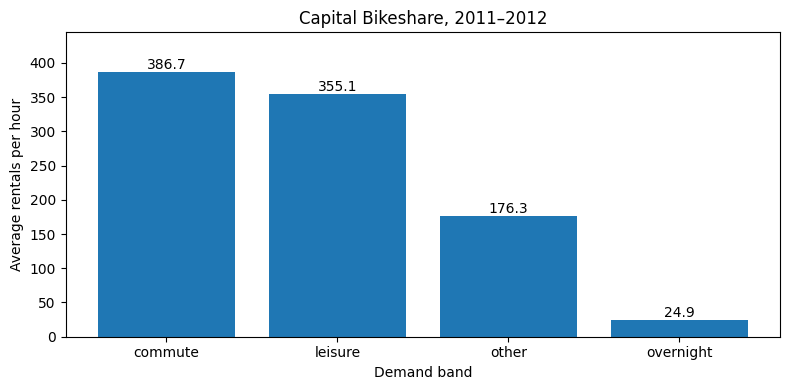

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt

order = ["commute", "leisure", "other", "overnight"]
pdf = counts.toPandas().set_index("band").loc[order].reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(pdf["band"], pdf["avg_rentals_per_hour"])
ax.set_ylabel("Average rentals per hour")
ax.set_xlabel("Demand band")
ax.set_title("Capital Bikeshare, 2011–2012")
ax.set_ylim(0, pdf["avg_rentals_per_hour"].max() * 1.15)
for bar, value in zip(bars, pdf["avg_rentals_per_hour"]):
    ax.annotate(
        f"{value:.1f}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
    )
fig.tight_layout()
plt.show()

The commute bar is the tallest (**386.7**), then leisure (**355.1**), then other (**176.3**), then overnight (**24.9**). The picture matches the count. Overnight covers about a quarter of the hours, and its bar stays short because the chart draws the rate.

### The same rates in Plotly

Same four averages from `pdf`. Plotly draws an interactive bar chart.

In [ ]:
import plotly.express as px

fig = px.bar(
    pdf,
    x="band",
    y="avg_rentals_per_hour",
    text="avg_rentals_per_hour",
    title="Capital Bikeshare, 2011–2012",
    labels={
        "band": "Demand band",
        "avg_rentals_per_hour": "Average rentals per hour",
    },
)
fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")
fig.update_layout(yaxis_range=[0, pdf["avg_rentals_per_hour"].max() * 1.15])
fig.show()

Hover a bar to read the rate. The heights match the matplotlib chart: commute **386.7**, leisure **355.1**, other **176.3**, overnight **24.9**.

## 7. Recommendation

Staff the two high-rate windows. Use the night for the workshop.

1. **Working days, 07:00–09:00 and 16:00–18:00.** This is the commute band: 386.7 rentals an hour, 35.0% of all rentals from 17.2% of the hours, and 90.7% of that band is members. Stage bikes before 07:00 and again before 16:00 on working days.
2. **Weekends and holidays, 11:00–16:00.** This is the leisure band: 355.1 rentals an hour. It holds 28.8% of all casual rentals in 8.0% of the hours, so the shift is there for walk-up riders. Sunday 3 June at 17:00 still had 578 rentals and stayed in `other`, so the scheduled window ends at 16:00.
3. **Midnight to 05:00.** Overnight averages 24.9 rentals an hour: 24.6% of the hours and 3.2% of the rentals. Use that block for maintenance and rebalancing.

That is the deliverable. The summary showed a usable two-year file, the `CASE` labeled each hour, the count measured the labels, the chart shows those rates, and these three shifts follow the rates.

In [17]:
spark.stop()